# 03 · Gradient-boosting challengers against the frozen baseline

**Question.** How much additional discrimination can gradient boosting extract from
the *same* application-table features that the Milestone 1 Logistic Regression
used, and what happens to probability quality (log loss, Brier score, calibration)
when it does?

**Principle.** The Milestone 1 holdout is frozen. It is reloaded from the persisted
membership file, verified against a re-derivation from the seed, and touched exactly
once per locked configuration, at the end. Every decision (hyper-parameters, early
stopping, the two preprocessing ablations) is made on a validation subset carved out
of the *training* portion only. Section 9 audits this in code.

**What this notebook deliberately does not do.** No class re-weighting, no
`scale_pos_weight`, no threshold, no recalibration: the objective is still an honest
estimate of `P(default | application)`, and calibration is *measured* so that the next
milestone knows whether it is needed.

**Division of labour.** The experiment is `riskpilot.models.challengers`
(`python -m riskpilot.models.challengers`); the frozen-split handling, the paired
bootstrap and the comparison figures are `riskpilot.models.comparison`; the tree
preprocessing is `riskpilot.features.tree_preprocessing`. The selection stage
(about 30 minutes of fitting) was run from the command line and its machine-readable
record (`artifacts/metrics/challenger_trials.csv`, `challenger_selection.json`) is
analysed here; the final stage (locked configurations on the frozen test split,
bootstrap, figures) is *re-executed* in this notebook and checked against the
command-line run.

In [1]:
import inspect
import json
import logging

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

from riskpilot import config
from riskpilot.data.load import categorize_strings, load_application_train, split_features_target
from riskpilot.features.tree_preprocessing import TreePreprocessor
from riskpilot.models import challengers as ch
from riskpilot.models import comparison as cmp
from riskpilot.models.evaluate import (
    GRID_COLOR,
    MODEL_COLOR,
    REFERENCE_COLOR,
    SECOND_COLOR,
    calibration_table,
)

logging.basicConfig(level=logging.INFO, format="%(levelname)s %(name)s: %(message)s")
pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 80)
plt.rcParams.update(
    {
        "figure.dpi": 110,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.edgecolor": GRID_COLOR,
        "axes.grid": True,
        "grid.color": GRID_COLOR,
        "grid.linewidth": 0.8,
        "axes.axisbelow": True,
        "legend.frameon": False,
    }
)
paths = ch.ExperimentPaths()
LIBS = list(ch.LIBRARIES)
LABEL = cmp.LABELS
KEYS = [
    "roc_auc", "average_precision", "log_loss", "brier_score", "brier_skill_score",
    "expected_calibration_error", "calibration_slope", "calibration_intercept",
]
print("versions:", {k: v for k, v in ch._run_info(0).items() if k.endswith("version")})

versions: {'riskpilot_version': '0.1.0', 'python_version': '3.12.5', 'sklearn_version': '1.9.1', 'lightgbm_version': '4.7.0', 'xgboost_version': '3.4.1'}


## 1. The frozen split and the frozen baseline

`load_frozen_split` rebuilds the partition from
`data/processed/baseline_split_membership.csv` and refuses to continue unless a
re-derivation from the seed reproduces it. `load_baseline_reference` reloads the
persisted Milestone 1 pipeline, scores the test partition and refuses to continue
unless the metrics match `artifacts/metrics/baseline_metrics.json`. The baseline is
therefore the very model reported in Milestone 1, not a refit.

In [2]:
df = load_application_train()
X, y = split_features_target(categorize_strings(df))  # strings as categoricals: half the memory, same values
ids = df[config.ID_COL]
del df
split = cmp.load_frozen_split(X, y, ids, membership_path=paths.membership_path)
del X, y
display(pd.Series(split.summary(), name="frozen split"))

baseline = cmp.load_baseline_reference(
    split, model_path=paths.baseline_model_path, metrics_path=paths.baseline_metrics_path
)
display(pd.Series(baseline.integrity, name="baseline integrity"))
recorded = json.loads(paths.baseline_metrics_path.read_text(encoding="utf-8"))["metrics"]["test"]
check = pd.DataFrame(
    {
        "recorded in Milestone 1": {k: recorded[k] for k in KEYS},
        "rescored from the persisted pipeline": {k: baseline.summary["metrics_test"][k] for k in KEYS},
    }
)
check["abs difference"] = (check.iloc[:, 0] - check.iloc[:, 1]).abs()
display(check.round(6))
print("baseline integrity confirmed:", baseline.integrity["metrics_match_recorded"], "| split verified:", split.verified_against_seed)

INFO riskpilot.data.load: Loaded application_train.csv: 307511 rows x 122 columns


strategy                           frozen Milestone 1 stratified holdout, reloade...
membership_file                    C:/Users/ricar/riskpilot-ai/data/processed/bas...
verified_against_reseeded_split                                                 True
n_train                                                                       246008
n_test                                                                         61503
n_test_positive                                                                 4965
prevalence_train                                                            0.080729
prevalence_test                                                             0.080728
Name: frozen split, dtype: object

model_reloaded_from_disk                                                              True
model_path                               C:/Users/ricar/riskpilot-ai/artifacts/models/b...
recorded_metrics_available                                                            True
split_verified_against_reseeded_split                                                 True
n_test_matches                                                                        True
max_abs_metric_difference                                                              0.0
tolerance                                                                         0.000001
metrics_match_recorded                                                                True
recorded_test_metrics                    {'roc_auc': 0.7504123473248321, 'average_preci...
Name: baseline integrity, dtype: object

,recorded in Milestone 1,rescored from the persisted pipeline,abs difference
roc_auc,0.750412,0.750412,0.0
average_precision,0.235318,0.235318,0.0
log_loss,0.248205,0.248205,0.0
brier_score,0.068216,0.068216,0.0
brier_skill_score,0.080782,0.080782,0.0
expected_calibration_error,0.002090,0.002090,0.0
calibration_slope,1.005561,1.005561,0.0
calibration_intercept,0.014821,0.014821,0.0


baseline integrity confirmed: True | split verified: True


## 2. Challenger setup: what trees need (and do not need)

The linear pipeline imputes, adds 62 missing indicators, standardizes and one-hot
encodes 16 string columns into 146 columns: 312 dense features. Gradient-boosted trees
are invariant to monotone rescaling, learn a default direction for missing values at
every split, and both LightGBM and XGBoost split natively on categorical columns.
`TreePreprocessor` therefore only cleans the sentinel, casts numerics to `float32` and
turns the 16 string columns into `pandas.Categorical` with the training vocabulary
(unseen levels become missing). One column per raw feature, no dimensional blow-up.
The two optional treatments used by the ablations (heavy-tail transform, missing
indicators) are shown here as fitted on the training portion.

In [3]:
pre = TreePreprocessor().fit(split.X_train)
Xt = pre.transform(split.X_train)
desc = pre.describe()
n_cat = sum(isinstance(d, pd.CategoricalDtype) for d in Xt.dtypes)
print(f"tree design matrix: {Xt.shape[0]:,} x {Xt.shape[1]} | {Xt.memory_usage(deep=True).sum() / 1e6:.0f} MB "
      f"| {Xt.shape[1] - n_cat} float32 + {n_cat} categorical columns | NaN cells kept: {int(Xt.isna().sum().sum()):,}")
print("linear design matrix (Milestone 1): 246,008 x 312 dense float64, about 614 MB")
print("categorical cardinality (max):", max(desc["categorical_cardinality"].values()), "| no imputation, no scaling, no one-hot, no indicators")
del Xt

heavy = TreePreprocessor(heavy_tail="winsorize").fit(split.X_train)
clip = pd.DataFrame(heavy.clip_bounds_, index=["clip_low (q0.1%)", "clip_high (q99.9%)"]).T
clip["train_max"] = [float(split.X_train[c].max()) for c in clip.index]
print("heavy-tail columns selected on the training portion (non-negative, unbounded, >= 20 distinct values, skew > 1):")
display(clip)

dedup = TreePreprocessor(missing_indicators="deduplicated").fit(split.X_train)
full = TreePreprocessor(missing_indicators="all").fit(split.X_train)
groups = [g for g in dedup.indicator_groups_ if len(g) > 1]
print(f"missing indicators: {len(full.indicator_columns_)} distinct-by-name, {len(dedup.indicator_columns_)} distinct-by-pattern "
      f"({len(full.indicator_columns_) - len(dedup.indicator_columns_)} exact duplicates in {len(groups)} groups, verified on the training portion)")
display(pd.Series({g[0]: len(g) for g in groups}, name="columns sharing one missingness pattern").sort_values(ascending=False).head(8))

tree design matrix: 246,008 x 120 | 108 MB | 104 float32 + 16 categorical columns | NaN cells kept: 7,362,588
linear design matrix (Milestone 1): 246,008 x 312 dense float64, about 614 MB
categorical cardinality (max): 58 | no imputation, no scaling, no one-hot, no indicators


heavy-tail columns selected on the training portion (non-negative, unbounded, >= 20 distinct values, skew > 1):


,clip_low (q0.1%),clip_high (q99.9%),train_max
AMT_INCOME_TOTAL,31500.000,900000.00,117000000.0
AMT_CREDIT,47970.000,2517300.00,4050000.0
AMT_ANNUITY,3923.973,111001.77,258025.5
AMT_GOODS_PRICE,45000.000,2250000.00,4050000.0
OWN_CAR_AGE,0.000,65.00,91.0
OBS_30_CNT_SOCIAL_CIRCLE,0.000,17.00,348.0
OBS_60_CNT_SOCIAL_CIRCLE,0.000,16.00,344.0
AMT_REQ_CREDIT_BUREAU_MON,0.000,12.00,27.0
AMT_REQ_CREDIT_BUREAU_YEAR,0.000,9.00,25.0


missing indicators: 62 distinct-by-name, 26 distinct-by-pattern (36 exact duplicates in 16 groups, verified on the training portion)


AMT_REQ_CREDIT_BUREAU_HOUR     6
OBS_30_CNT_SOCIAL_CIRCLE       4
APARTMENTS_AVG                 3
BASEMENTAREA_AVG               3
COMMONAREA_AVG                 3
ELEVATORS_AVG                  3
YEARS_BEGINEXPLUATATION_AVG    3
YEARS_BUILD_AVG                3
Name: columns sharing one missingness pattern, dtype: int64

**Reading.** The tree design matrix is 246,008 × 120 and about 108 MB (104 `float32` + 16 categorical columns, with every missing cell kept as missing), against 312 dense `float64` columns and about 614 MB for the linear pipeline: a 2.6 × narrower and nearly 6 × lighter representation that loses nothing a tree can use. The data-driven heavy-tail rule selects nine columns on the training portion: the four monetary amounts (`AMT_INCOME_TOTAL`, `AMT_CREDIT`, `AMT_ANNUITY`, `AMT_GOODS_PRICE`), the two social-circle observation counts, two credit-bureau enquiry counts and `OWN_CAR_AGE`; the 117,000,000 income sits far above the training 99.9th percentile that winsorization would clip it to. Of the 62 missing indicators the linear pipeline builds, only 26 missingness patterns are distinct: 36 indicators are exact duplicates of another one (the `_AVG/_MODE/_MEDI` building triples share one pattern each), verified column by column rather than assumed.

## 3. Internal validation protocol

The 246,008 training rows are split once more, stratified, seed 42, into a fit subset
and a validation subset (`config.VALIDATION_SIZE = 0.2`). Every challenger is fitted
on the fit subset with early stopping on the validation log loss (patience 100 rounds,
cap 5,000); the Logistic Regression pipeline is refitted on the same fit subset so
that the challengers have a like-for-like reference *before* the test split is
involved. Validation log loss is the selection criterion: it is a proper scoring rule,
so it rewards ranking and probability quality together; ROC-AUC, PR-AUC, Brier and ECE
are recorded for every trial so nothing is optimized blindly.

In [4]:
selection = json.loads(paths.selection_path.read_text(encoding="utf-8"))
trials = pd.read_csv(paths.trials_path)
display(pd.Series(selection["validation_split"], name="validation split (inside the training portion)"))
print("selection metric:", selection["selection_metric"])
show = ["trial_id", "stage", "description", "n_features", "n_trees", "fit_seconds",
        "val_log_loss", "val_roc_auc", "val_average_precision", "val_brier_score",
        "val_expected_calibration_error", "val_calibration_slope"]
display(trials.loc[trials["stage"].isin(["reference", "initial"]), show].round(5))

strategy            stratified random holdout carved out of the fr...
valid_size                                                        0.2
random_state                                                       42
n_fit                                                          196806
n_valid                                                         49202
prevalence_fit                                               0.080729
prevalence_valid                                             0.080728
Name: validation split (inside the training portion), dtype: object

selection metric: validation log_loss (lower is better); ROC-AUC, PR-AUC, Brier and ECE recorded for every trial


,trial_id,stage,description,n_features,n_trees,fit_seconds,val_log_loss,val_roc_auc,val_average_precision,val_brier_score,val_expected_calibration_error,val_calibration_slope
0,logistic_regression-ref,reference,Milestone 1 baseline pipeline refitted on the ...,312,NaN,19.99,0.25049,0.74428,0.22166,0.06882,0.00258,0.95698
1,lightgbm-01,initial,starting configuration,120,370.0,8.51,0.24782,0.75293,0.23439,0.06826,0.00449,0.95233
17,xgboost-01,initial,starting configuration,120,219.0,30.93,0.24845,0.75028,0.23177,0.06835,0.00435,0.96713


**Reading.** Refitted on the 196,806-row fit subset, the Milestone 1 pipeline scores the 49,202 validation rows at log loss 0.2505 and ROC-AUC 0.744, a shade below its test-set figures (the validation subset is a different sample). The untuned starting configurations already beat it on every metric: LightGBM at log loss 0.2478 / ROC-AUC 0.753 (370 trees) and XGBoost at 0.2485 / 0.750 (219 trees). Every model, the linear one included, has a validation calibration slope between 0.95 and 0.97, i.e. is very slightly over-confident on this particular subset; the differences between models on that axis are within sampling noise.

## 4. Tuning: a compact coordinate descent

One axis at a time, in a fixed order, three values per axis at most, the winner on
validation log loss carried forward. That is 12 fits per library instead of a grid of
several hundred. Every fit is in `challenger_trials.csv`.

In [5]:
search = trials[trials["stage"].str.startswith(("initial", "search"))].copy()
for lib in LIBS:
    entry = selection["libraries"][lib]
    block = search[search["library"] == lib]
    display(Markdown(f"**{LABEL[lib]}** — {len(block)} search trials; best search trial `{entry['search_best_trial']}`"))
    display(block[show].round(5).style.hide(axis="index").highlight_min(subset=["val_log_loss"], color="#fde9d9"))

**LightGBM** — 12 search trials; best search trial `lightgbm-12`

trial_id,stage,description,n_features,n_trees,fit_seconds,val_log_loss,val_roc_auc,val_average_precision,val_brier_score,val_expected_calibration_error,val_calibration_slope
lightgbm-01,initial,starting configuration,120,370.000000,8.510000,0.247820,0.752930,0.234390,0.068260,0.004490,0.952330
lightgbm-02,search:num_leaves,num_leaves=15,120,441.000000,9.710000,0.247620,0.753550,0.235800,0.068190,0.003090,0.970910
lightgbm-03,search:num_leaves,num_leaves=63,120,210.000000,9.640000,0.248210,0.752060,0.232920,0.068350,0.003720,0.954550
lightgbm-04,search:min_child_samples,min_child_samples=20,120,452.000000,6.670000,0.247900,0.752270,0.235360,0.068220,0.002900,0.969680
lightgbm-05,search:min_child_samples,min_child_samples=500,120,575.000000,7.960000,0.247470,0.753790,0.236800,0.068140,0.003250,0.955790
lightgbm-06,search:colsample_bytree,colsample_bytree=0.3,120,611.000000,10.960000,0.247320,0.754710,0.237090,0.068130,0.003820,0.968400
lightgbm-07,search:colsample_bytree,colsample_bytree=0.5,120,570.000000,12.770000,0.247290,0.754380,0.237740,0.068100,0.003530,0.967540
lightgbm-08,search:subsample,subsample=0.6,120,558.000000,13.520000,0.247410,0.753980,0.237740,0.068130,0.003020,0.963520
lightgbm-09,search:subsample,subsample=1.0,120,583.000000,12.980000,0.247400,0.753820,0.237530,0.068110,0.002490,0.965780
lightgbm-10,search:reg_lambda,reg_lambda=0.0,120,587.000000,13.350000,0.247380,0.754180,0.237450,0.068130,0.004040,0.965140


**XGBoost** — 12 search trials; best search trial `xgboost-11`

trial_id,stage,description,n_features,n_trees,fit_seconds,val_log_loss,val_roc_auc,val_average_precision,val_brier_score,val_expected_calibration_error,val_calibration_slope
xgboost-01,initial,starting configuration,120,219.000000,30.930000,0.248450,0.750280,0.231770,0.068350,0.004350,0.967130
xgboost-02,search:max_depth,max_depth=3,120,768.000000,55.830000,0.247430,0.754220,0.235950,0.068150,0.002960,0.971850
xgboost-03,search:max_depth,max_depth=4,120,634.000000,52.430000,0.247780,0.752670,0.236210,0.068190,0.003630,0.952960
xgboost-04,search:min_child_weight,min_child_weight=1,120,766.000000,55.350000,0.247420,0.753910,0.236540,0.068130,0.003440,0.970800
xgboost-05,search:min_child_weight,min_child_weight=100,120,922.000000,67.800000,0.247470,0.753840,0.236570,0.068150,0.003390,0.962320
xgboost-06,search:colsample_bytree,colsample_bytree=0.3,120,1088.000000,2511.410000,0.247250,0.754970,0.237030,0.068130,0.002710,0.970660
xgboost-07,search:colsample_bytree,colsample_bytree=0.5,120,644.000000,46.220000,0.247290,0.754550,0.237160,0.068110,0.002780,0.988430
xgboost-08,search:subsample,subsample=0.6,120,1062.000000,73.150000,0.247480,0.754520,0.235660,0.068190,0.003890,0.968100
xgboost-09,search:subsample,subsample=1.0,120,1003.000000,74.340000,0.247310,0.755020,0.236240,0.068150,0.003530,0.973300
xgboost-10,search:reg_lambda,reg_lambda=10.0,120,1123.000000,81.900000,0.247060,0.755620,0.237760,0.068080,0.003530,0.972060


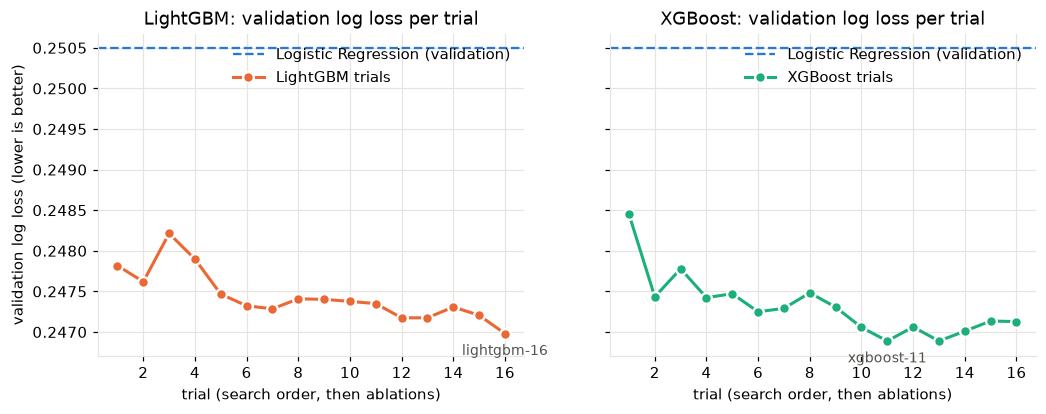

In [6]:
ref_ll = float(trials.loc[trials["library"] == "logistic_regression", "val_log_loss"].iloc[0])
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for ax, lib, color in zip(axes, LIBS, [SECOND_COLOR, cmp.SERIES_COLORS["xgboost"]]):
    block = trials[trials["library"] == lib].reset_index(drop=True)
    ax.axhline(ref_ll, color=MODEL_COLOR, linewidth=1.5, linestyle="--", label="Logistic Regression (validation)")
    ax.plot(block.index + 1, block["val_log_loss"], color=color, linewidth=2, marker="o", markersize=7,
            markeredgecolor="white", markeredgewidth=1.5, label=f"{LABEL[lib]} trials")
    best = block["val_log_loss"].idxmin()
    ax.annotate(block.loc[best, "trial_id"], (best + 1, block.loc[best, "val_log_loss"]),
                textcoords="offset points", xytext=(0, -14), ha="center", fontsize=9, color="#52514e")
    ax.set_title(f"{LABEL[lib]}: validation log loss per trial")
    ax.set_xlabel("trial (search order, then ablations)")
    ax.legend(loc="upper right")
axes[0].set_ylabel("validation log loss (lower is better)")
plt.show()

**Reading.** The whole search moves validation log loss by less than 0.001: LightGBM from 0.2478 to 0.2472, XGBoost from 0.2485 to 0.2469. For LightGBM, fewer leaves (15) with large leaves (min 500 samples), half the features per tree and a slower learning rate (0.02, 1,380 rounds) won; row subsampling and L2 strength did not matter. For XGBoost, shallow trees (depth 3) with 30 % of the features per tree and strong regularization (λ = 10, α = 1) won; a slower learning rate did not help. Both searches converge on the same recipe, many small, heavily regularized, feature-subsampled trees, which is what one expects from 120 noisy application features and an 8 % event rate. The tuning gain (about 0.0006 in log loss) is a fifth of the gain over the linear reference (about 0.0035): the model class matters, the hyper-parameters barely do. One XGBoost trial (colsample 0.3) records a 2,511 s fit; that is wall time on a laptop that was paging memory at the time, not model cost (the same configuration refits in about 80 s).

## 5. Ablations on the best configuration

Two controlled comparisons per library, on validation data, starting from the best
searched configuration. A variant is adopted only if it lowers the validation log loss
by at least 0.0005 (parsimony: added preprocessing must earn its place).

* **Heavy tails.** `log1p` or winsorization (training-split 0.1 / 99.9 percentiles) of
  the skewed non-negative columns listed in section 2.
* **Missing indicators.** `none` (the libraries' native missing handling, the
  default) vs. all 62 indicators of the linear pipeline vs. the de-duplicated set.

In [7]:
abl = trials[trials["stage"].str.startswith("ablation")].copy()
cols = ["trial_id", "stage", "description", "n_features", "n_trees", "fit_seconds",
        "val_log_loss", "val_roc_auc", "val_average_precision", "val_expected_calibration_error"]
for lib in LIBS:
    entry = selection["libraries"][lib]
    incumbent = trials[trials["trial_id"] == entry["search_best_trial"]]
    block = pd.concat([incumbent, abl[abl["library"] == lib]])
    display(Markdown(f"**{LABEL[lib]}** — incumbent `{entry['search_best_trial']}` vs. variants"))
    display(block[cols].round(5).style.hide(axis="index"))
    for name, a in entry["ablations"].items():
        print(f"  {name:>18}: best variant '{a['best_candidate']}' gains {a['gain_in_val_log_loss']:+.5f} in validation log loss "
              f"(threshold {a['min_gain_to_adopt']}) -> adopted: {a['adopted']}")
    print(f"  locked: trial {entry['selected_trial']}, {entry['locked_n_estimators']} rounds, "
          f"heavy_tail={entry['locked_spec']['heavy_tail']}, missing_indicators={entry['locked_spec']['missing_indicators']}")

**LightGBM** — incumbent `lightgbm-12` vs. variants

trial_id,stage,description,n_features,n_trees,fit_seconds,val_log_loss,val_roc_auc,val_average_precision,val_expected_calibration_error
lightgbm-12,search:learning_rate,learning_rate=0.02,120,1380.000000,26.760000,0.247170,0.754680,0.237950,0.003500
lightgbm-13,ablation:heavy_tail,log1p,120,1380.000000,27.980000,0.247170,0.754680,0.237950,0.003500
lightgbm-14,ablation:heavy_tail,winsorize,120,1141.000000,16.420000,0.247310,0.754240,0.237600,0.003240
lightgbm-15,ablation:missing_indicators,all,182,1347.000000,36.080000,0.247210,0.754510,0.238340,0.003290
lightgbm-16,ablation:missing_indicators,deduplicated,146,1553.000000,20.440000,0.246980,0.755330,0.239510,0.002910


          heavy_tail: best variant 'log1p' gains +0.00000 in validation log loss (threshold 0.0005) -> adopted: None
  missing_indicators: best variant 'deduplicated' gains +0.00019 in validation log loss (threshold 0.0005) -> adopted: None
  locked: trial lightgbm-12, 1380 rounds, heavy_tail=none, missing_indicators=none


**XGBoost** — incumbent `xgboost-11` vs. variants

trial_id,stage,description,n_features,n_trees,fit_seconds,val_log_loss,val_roc_auc,val_average_precision,val_expected_calibration_error
xgboost-11,search:reg_alpha,reg_alpha=1.0,120,1140.000000,81.610000,0.246890,0.756220,0.238230,0.002920
xgboost-13,ablation:heavy_tail,log1p,120,1140.000000,85.360000,0.246890,0.756220,0.238230,0.002920
xgboost-14,ablation:heavy_tail,winsorize,120,1140.000000,88.800000,0.247010,0.755890,0.237640,0.003170
xgboost-15,ablation:missing_indicators,all,182,1142.000000,130.900000,0.247140,0.755510,0.236880,0.002370
xgboost-16,ablation:missing_indicators,deduplicated,146,1150.000000,103.700000,0.247130,0.755290,0.237940,0.003320


          heavy_tail: best variant 'log1p' gains +0.00000 in validation log loss (threshold 0.0005) -> adopted: None
  missing_indicators: best variant 'deduplicated' gains -0.00024 in validation log loss (threshold 0.0005) -> adopted: None
  locked: trial xgboost-11, 1140 rounds, heavy_tail=none, missing_indicators=none


**Reading.** **Heavy tails.** `log1p` reproduces the incumbent exactly (identical log loss, ROC-AUC and number of trees for both libraries): histogram-based boosting bins each feature by quantiles, and a monotone transform does not change the quantile order, so the model is literally the same. Winsorization at the training 0.1 / 99.9 percentiles merges the tails into one bin and is slightly worse (+0.00014 / +0.00012 log loss). Neither is adopted: the treatment that deserved a full section for the standardized linear model is a no-op for trees. **Missing indicators.** Adding the 62 indicators makes both models slightly worse (LightGBM +0.00004, XGBoost +0.00025) at 182 features and 30–60 % longer fits; the de-duplicated 26 help LightGBM by 0.00019 and hurt XGBoost by 0.00024, both inside noise and below the 0.0005 adoption threshold. Native missing handling (a learned default direction per split) already carries the information. Neither is adopted; both locked configurations use the 120 raw features.

## 6. Locked configurations on the frozen test split

The locked specifications (parameters *and* number of boosting rounds) are refitted on
the whole training portion without early stopping, and each scores the test split
once. This cell re-executes the final stage and checks it against the command-line run
recorded in `artifacts/metrics/{lightgbm,xgboost}_metrics.json` (a determinism check:
same data, same seed, same thread count).

In [8]:
for lib in LIBS:
    spec = selection["libraries"][lib]["locked_spec"]
    print(f"{LABEL[lib]:>19}: {json.dumps({k: v for k, v in spec['params'].items() if k not in ('objective', 'eval_metric', 'tree_method', 'enable_categorical', 'verbose', 'verbosity', 'random_state')})}")
previous = {lib: json.loads(paths.metrics_path(lib).read_text(encoding="utf-8")) for lib in LIBS}
final = ch.run_final_stage(split, selection, paths, ch.FinalConfig(n_bootstrap=1000))
for lib in LIBS:
    same = all(np.isclose(final["summaries"][lib]["metrics_test"][k], previous[lib]["metrics"]["test"][k], atol=1e-9) for k in KEYS)
    print(f"{LABEL[lib]}: notebook refit reproduces the command-line test metrics: {same} "
          f"(trees {final['summaries'][lib]['n_trees']} vs {previous[lib]['model']['n_trees']})")
print("baseline integrity:", final["baseline_integrity"]["metrics_match_recorded"])

           LightGBM: {"learning_rate": 0.02, "n_estimators": 1380, "num_leaves": 15, "max_depth": -1, "min_child_samples": 500, "subsample": 0.8, "subsample_freq": 1, "colsample_bytree": 0.5, "reg_alpha": 0.0, "reg_lambda": 1.0, "n_jobs": 6}
            XGBoost: {"learning_rate": 0.05, "n_estimators": 1140, "max_depth": 3, "min_child_weight": 1, "subsample": 0.8, "colsample_bytree": 0.3, "reg_alpha": 1.0, "reg_lambda": 10.0, "n_jobs": 6}


INFO riskpilot.models.challengers: Final lightgbm: refitting locked spec (1380 rounds) on 246008 rows


INFO riskpilot.models.challengers: Final lightgbm on the frozen test split: ROC-AUC 0.7622 | AP 0.2538 | log loss 0.24456 | Brier 0.06739 | ECE 0.0022


INFO riskpilot.models.challengers: Final xgboost: refitting locked spec (1140 rounds) on 246008 rows


INFO riskpilot.models.challengers: Final xgboost on the frozen test split: ROC-AUC 0.7617 | AP 0.2522 | log loss 0.24471 | Brier 0.06743 | ECE 0.0023


LightGBM: notebook refit reproduces the command-line test metrics: True (trees 1380 vs 1380)
XGBoost: notebook refit reproduces the command-line test metrics: True (trees 1140 vs 1140)
baseline integrity: True


In [9]:
table = final["comparison_table"].set_index("model")
main = ["roc_auc", "average_precision", "log_loss", "brier_score", "brier_skill_score", "expected_calibration_error"]
display(table[main].round(4))
deltas = table[[f"delta_{k}" for k in cmp.BOOTSTRAP_METRICS] + [f"rel_{k}_pct" for k in cmp.BOOTSTRAP_METRICS]].round(4)
deltas.columns = [c.replace("delta_", "Δ ").replace("rel_", "Δ% ").replace("_pct", "") for c in deltas.columns]
display(deltas)
cost = table[["n_features", "n_trees", "fit_seconds", "predict_seconds_test", "model_size_mb", "train_roc_auc", "train_log_loss"]]
display(cost)

,roc_auc,average_precision,log_loss,brier_score,brier_skill_score,expected_calibration_error
model,,,,,,
Logistic Regression,0.7504,0.2353,0.2482,0.0682,0.0808,0.0021
LightGBM,0.7622,0.2538,0.2446,0.0674,0.0919,0.0022
XGBoost,0.7617,0.2522,0.2447,0.0674,0.0914,0.0023


,Δ roc_auc,Δ average_precision,Δ log_loss,Δ brier_score,Δ% roc_auc,Δ% average_precision,Δ% log_loss,Δ% brier_score
model,,,,,,,,
Logistic Regression,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
LightGBM,0.0118,0.0185,-0.0036,-0.0008,1.5708,7.8564,-1.4700,-1.2096
XGBoost,0.0113,0.0169,-0.0035,-0.0008,1.5065,7.1674,-1.4088,-1.1542


,n_features,n_trees,fit_seconds,predict_seconds_test,model_size_mb,train_roc_auc,train_log_loss
model,,,,,,,
Logistic Regression,312,NaN,32.10,0.559,0.027,0.751228,0.248407
LightGBM,120,1380.0,37.21,1.860,2.552,0.802706,0.232883
XGBoost,120,1140.0,35.44,0.844,1.515,0.788490,0.237165


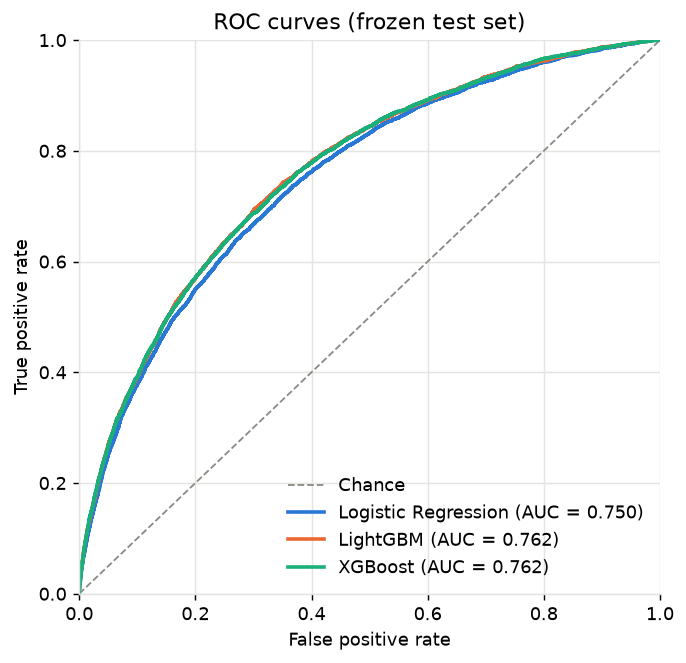

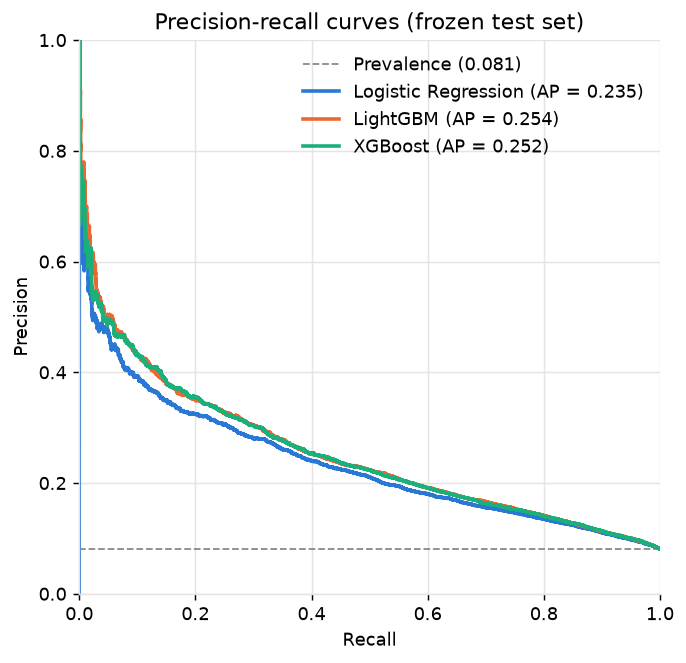

In [10]:
for key in ("roc_comparison", "precision_recall_comparison"):
    display(Image(filename=str(config.PROJECT_ROOT / final["artifacts"]["figures"][key]), width=480))

**Reading.** Both challengers beat the frozen baseline on every metric, on the identical 61,503 rows, and by almost the same amount: ROC-AUC 0.7622 (LightGBM) and 0.7617 (XGBoost) against 0.7504, i.e. +0.012 / +0.011 absolute (+1.6 % / +1.5 % relative); average precision 0.2538 / 0.2522 against 0.2353 (+7.9 % / +7.2 % relative, the largest gain because PR-AUC rewards the top of the ranking, where the extra non-linear signal lands); log loss 0.2446 / 0.2447 against 0.2482 (−1.5 % / −1.4 %); Brier 0.06739 / 0.06743 against 0.06822 (−1.2 %); Brier skill score 0.092 / 0.091 against 0.081. Discrimination improved and probability quality improved with it: nothing was traded away. The train–test gap is where the model classes differ: the linear model generalizes perfectly (train ROC-AUC 0.751 vs test 0.750) while LightGBM reaches 0.803 on its training rows (gap 0.04) and XGBoost 0.788 (gap 0.027). That is the ordinary optimism of boosted trees, contained by small leaves, feature subsampling and locked round counts, and section 7 shows it does not turn into test-set over-confidence. Cost: fitting takes about the same wall time as the linear baseline (37 s and 35 s against 32 s, on 6 threads), scoring the test rows takes 1.9 s (LightGBM) and 0.8 s (XGBoost) against 0.6 s, and the persisted pipelines weigh 2.6 MB and 1.5 MB against 27 KB. The notebook refits reproduce the command-line metrics to the last digit (same data, seed and thread count).

## 7. Calibration diagnostics

Ten-quantile reliability tables for the three models on the same test rows, the
slope / intercept diagnostic (logistic regression of the outcome on the predicted
log-odds; 1 / 0 is calibrated, slope < 1 over-confident, > 1 under-confident), ECE,
and the uniform-bin tail counts. Nothing here alters the predictions.

Logistic Regression                             LightGBM                              XGBoost                      
         mean_predicted observed_rate     gap mean_predicted observed_rate     gap mean_predicted observed_rate     gap
bin                                                                                                                    
0                0.0119        0.0150  0.0031         0.0135        0.0124 -0.0012         0.0124        0.0125  0.0001
1                0.0214        0.0215  0.0001         0.0217        0.0202 -0.0016         0.0211        0.0180 -0.0031
2                0.0299        0.0291 -0.0008         0.0289        0.0285 -0.0005         0.0288        0.0312  0.0024
3                0.0390        0.0358 -0.0032         0.0370        0.0351 -0.0018         0.0373        0.0335 -0.0038
4                0.0495        0.0491 -0.0004         0.0466        0.0433 -0.0034         0.0473        0.0442 -0.0031
5                0.0624        0.0613 -0.0011         0.0590        0.0592  0.0002         0.0598        0.0598  0.0001
6                0.0797        0.0800  0.0003         0.0759        0.0802  0.0043         0.0765        0.0800  0.0035
7                0.1042        0.1033 -0.0010         0.1009        0.0995 -0.0014         0.1012        0.1024  0.0012
8                0.1449        0.1420 -0.0030         0.1446        0.1496  0.0050         0.1439        0.1472  0.0033
9                0.2623        0.2704  0.0081         0.2769        0.2795  0.0026         0.2759        0.2783  0.0024

,Logistic Regression,LightGBM,XGBoost
mean predicted,0.0805,0.0805,0.0804
observed prevalence,0.0807,0.0807,0.0807
calibration slope,1.0056,1.0220,1.0180
calibration intercept,0.0148,0.0491,0.0419
ECE (10 quantile bins),0.0021,0.0022,0.0023
max predicted,0.7443,0.7844,0.8020
n test rows scored > 0.5,108.0000,197.0000,213.0000


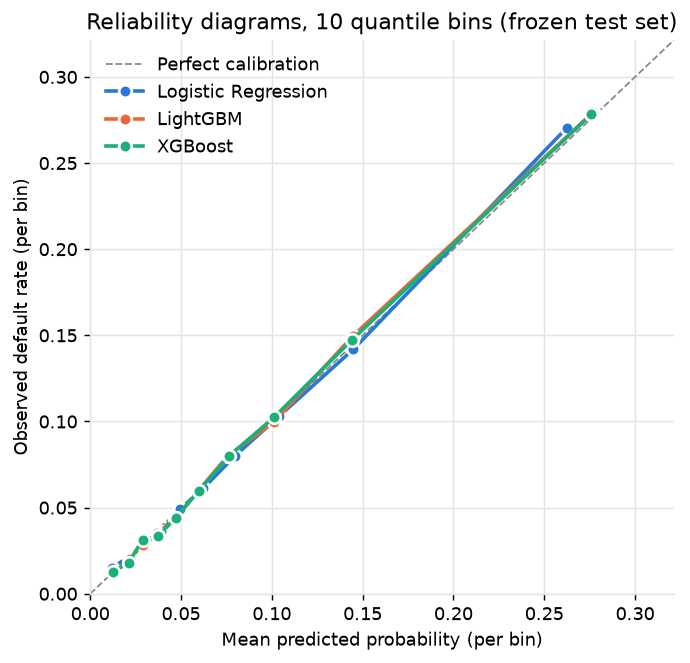

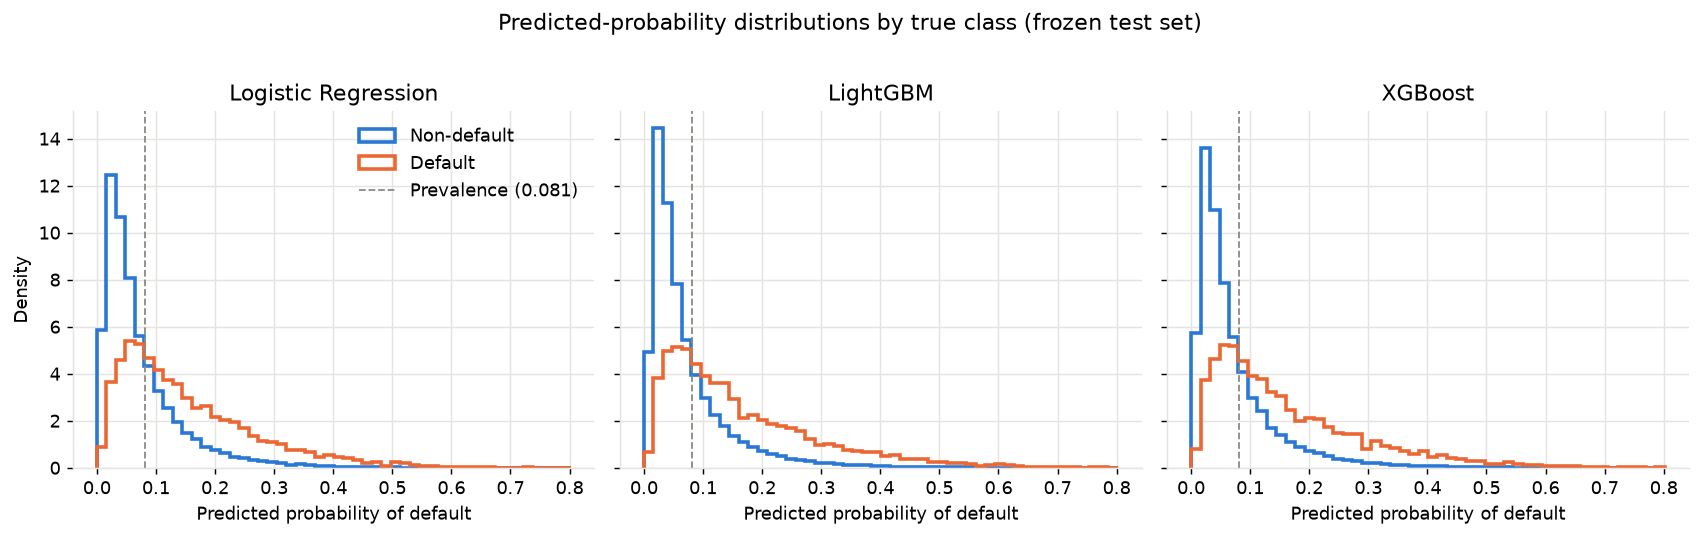

In [11]:
preds = final["predictions"]
y_test = split.y_test.to_numpy()
rel = {}
for name, p in preds.items():
    t = calibration_table(y_test, p, n_bins=10)
    rel[LABEL[name]] = t.set_index("bin")[["mean_predicted", "observed_rate", "gap"]]
display(pd.concat(rel, axis=1).round(4))

diag = pd.DataFrame({LABEL[k]: {
    "mean predicted": v["metrics_test"]["mean_predicted_probability"],
    "observed prevalence": float(y_test.mean()),
    "calibration slope": v["metrics_test"]["calibration_slope"],
    "calibration intercept": v["metrics_test"]["calibration_intercept"],
    "ECE (10 quantile bins)": v["metrics_test"]["expected_calibration_error"],
    "max predicted": v["metrics_test"]["max_predicted_probability"],
    "n test rows scored > 0.5": int((preds[k] > 0.5).sum()),
} for k, v in final["summaries"].items()})
display(diag.round(4))
for key in ("calibration_comparison", "probability_distributions"):
    display(Image(filename=str(config.PROJECT_ROOT / final["artifacts"]["figures"][key]), width=560 if key == "calibration_comparison" else 900))

**Reading.** Both challengers are calibrated in the large (mean predicted 0.0805 / 0.0804 vs 0.0807 observed) and in shape: slope 1.022 / 1.018, intercept 0.049 / 0.042, ECE 0.0022 / 0.0023 on ten quantile bins against 0.0021 for the baseline, and every decile gap is below half a percentage point (the largest, +0.50 pp, is LightGBM's ninth decile, 0.1446 predicted vs 0.1496 observed). A slope slightly above 1 means the probabilities are, if anything, marginally *under*-confident (the log-odds could be stretched a little further from the base rate), which is the mild, safe direction; with 61,503 rows the slope's sampling error is about ± 0.03, so 1.02 is not distinguishable from 1. The tail widened as discrimination improved: 197 / 213 test applicants are now scored above 0.5 (108 for the baseline) and the 99th percentile of the predictions moved from 0.374 to 0.408; the top decile (0.277 predicted vs 0.280 observed) remains calibrated. Verdict: neither challenger is over-confident and neither needs formal recalibration; the calibration milestone should treat these probabilities as a strong null and demonstrate any Platt / isotonic gain on a proper held-out design rather than assume one.

## 8. Uncertainty: paired bootstrap on the frozen test predictions

1,000 resamples of the 61,503 test rows (seed 42); every model is scored on the *same*
resample, so the intervals describe the uncertainty of the *difference*, which is the
quantity of interest. `fraction_improving` is the share of resamples in which the
challenger beats the reference; it is a stability summary, not a significance test.

,comparison,metric,difference,ci95_low,ci95_high,bootstrap_sd,fraction_improving,ci_excludes_zero
0,LightGBM − Logistic Regression,roc_auc,0.01179,0.00917,0.01448,0.00133,1.000,True
1,LightGBM − Logistic Regression,average_precision,0.01849,0.01302,0.02355,0.00269,1.000,True
2,LightGBM − Logistic Regression,log_loss,-0.00365,-0.00436,-0.00296,0.00037,1.000,True
3,LightGBM − Logistic Regression,brier_score,-0.00083,-0.00102,-0.00063,0.00010,1.000,True
4,XGBoost − Logistic Regression,roc_auc,0.01130,0.00867,0.01395,0.00133,1.000,True
5,XGBoost − Logistic Regression,average_precision,0.01687,0.01155,0.02152,0.00257,1.000,True
6,XGBoost − Logistic Regression,log_loss,-0.00350,-0.00422,-0.00278,0.00037,1.000,True
7,XGBoost − Logistic Regression,brier_score,-0.00079,-0.00097,-0.00058,0.00010,1.000,True
8,XGBoost − LightGBM,roc_auc,-0.00048,-0.00148,0.00052,0.00052,0.180,False
9,XGBoost − LightGBM,average_precision,-0.00162,-0.00364,0.00036,0.00102,0.058,False


re-running the bootstrap with seed 42 reproduces every interval: True


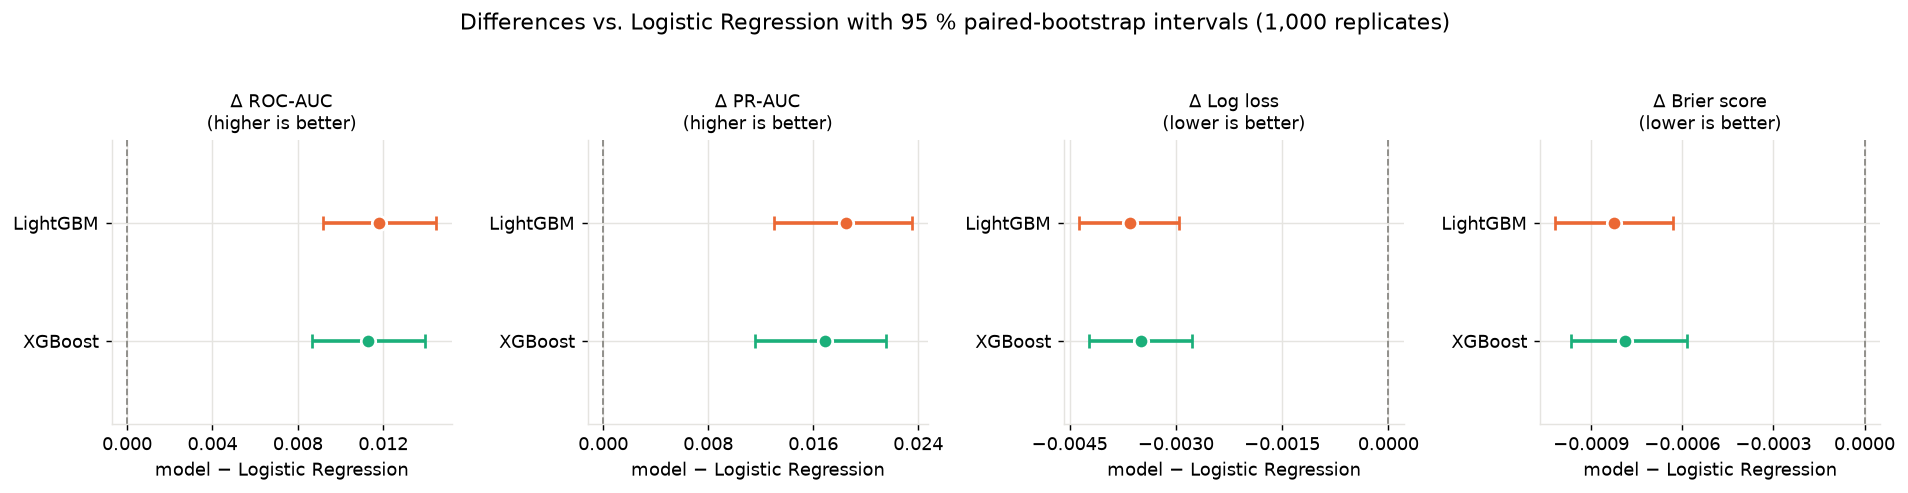

In [12]:
boot = final["bootstrap"]
rows = []
for pair, entry in boot["differences"].items():
    for metric in boot["metrics"]:
        s = entry[metric]
        rows.append({"comparison": f"{LABEL[entry['model']]} − {LABEL[entry['reference']]}", "metric": metric,
                     "difference": s["estimate"], "ci95_low": s["ci_low"], "ci95_high": s["ci_high"],
                     "bootstrap_sd": s["bootstrap_sd"], "fraction_improving": s["fraction_improving"],
                     "ci_excludes_zero": s["ci_excludes_zero"]})
display(pd.DataFrame(rows).round(5))

again = cmp.paired_bootstrap(y_test, preds, n_replicates=boot["n_replicates"], seed=boot["seed"])
same = all(
    again["differences"][pair][m][k] == boot["differences"][pair][m][k]
    for pair in boot["differences"] for m in boot["metrics"] for k in ("ci_low", "ci_high", "fraction_improving")
)
print(f"re-running the bootstrap with seed {boot['seed']} reproduces every interval: {same}")
display(Image(filename=str(config.PROJECT_ROOT / final["artifacts"]["figures"]["delta_bootstrap"]), width=1000))

**Reading.** Every challenger-vs-baseline difference has a 95 % paired-bootstrap interval that excludes zero, and the challenger wins in all 1,000 resamples: ΔROC-AUC +0.0118 [+0.0092, +0.0145] for LightGBM and +0.0113 [+0.0087, +0.0140] for XGBoost; ΔPR-AUC +0.0185 [+0.0130, +0.0236] and +0.0169 [+0.0116, +0.0215]; Δlog loss −0.0037 [−0.0044, −0.0030] and −0.0035 [−0.0042, −0.0028]; ΔBrier −0.0008 [−0.0010, −0.0006] for both. The lower bounds sit roughly seven bootstrap standard deviations from zero, so the improvement is stable, not a lucky split. Between the two challengers nothing is resolved: ΔROC-AUC −0.0005 [−0.0015, +0.0005], ΔPR-AUC −0.0016 [−0.0036, +0.0004], Δlog loss +0.00015 [−0.0001, +0.0004]; XGBoost is nominally behind on every metric, but every interval includes zero and the two prediction vectors correlate at 0.99. These are confidence intervals for the observed differences on this holdout, not claims of statistical significance in the hypothesis-testing sense. The same seed reproduces every interval exactly, as the cell above confirms.

## 9. Test-set leakage audit

Two guarantees, checked in code rather than asserted: the selection stage cannot
receive test rows (its signature has no test argument), and the only functions in the
experiment modules whose source references the test partition are the ones that
partition the data, score the frozen baseline, and score the locked models.

In [13]:
print("run_selection_stage", inspect.signature(ch.run_selection_stage))
for mod in (ch, cmp):
    touching = [n for n, f in inspect.getmembers(mod, inspect.isfunction)
                if f.__module__ == mod.__name__ and "X_test" in inspect.getsource(f)]
    print(f"functions in {mod.__name__} whose source touches X_test: {touching}")
print("early stopping in the final refit:", {lib: previous[lib]["model"]["early_stopping"] for lib in LIBS})
print("preprocessing fitted on:", "split.X_train only (TreePreprocessor.fit inside fit_challenger)")

run_selection_stage (X_train: 'pd.DataFrame', y_train: 'pd.Series', cfg: 'SelectionConfig | None' = None, *, log: 'TrialLog | None' = None) -> 'dict[str, Any]'
functions in riskpilot.models.challengers whose source touches X_test: ['run_final_stage']
functions in riskpilot.models.comparison whose source touches X_test: ['load_baseline_reference', 'load_frozen_split']
early stopping in the final refit: {'lightgbm': 'none (rounds locked during selection)', 'xgboost': 'none (rounds locked during selection)'}
preprocessing fitted on: split.X_train only (TreePreprocessor.fit inside fit_challenger)


## 10. Conclusions

* **Gradient boosting on the same 120 application features adds about +0.012 ROC-AUC and +0.018 PR-AUC** over the frozen Logistic Regression baseline, cuts log loss by 1.5 % and Brier score by 1.2 %, with 95 % paired-bootstrap intervals well clear of zero on the identical 61,503 test rows. **Calibration is preserved** (ECE 0.0022 vs 0.0021, slope 1.02, mean prediction equal to the prevalence), so discrimination was gained without paying in probability quality.
* **LightGBM and XGBoost are statistically indistinguishable** on this data (every pairwise interval includes zero; predictions correlate at 0.99). LightGBM is nominally best on every metric and its search was the cheaper one.
* **Tuning barely matters, the model class does.** The compact coordinate descent moved validation log loss by less than 0.001, a fifth of the gap to the linear model; both libraries converged on many small, heavily regularized, feature-subsampled trees.
* **The ablations were no-ops for trees, and that is a finding.** `log1p` reproduces the models exactly (quantile binning is invariant to monotone transforms), winsorization is marginally worse, and the missing indicators that the linear model needs add nothing to models that learn a default direction for missing values. Both locked configurations use the 120 raw features with native missing handling and no scaling.
* **The frozen split was never used for any decision** (section 9): early stopping and every selection happened on a validation subset of the training portion; the test partition was scored once per locked configuration.
* **The remaining ceiling is the data, not the model class:** published solutions reach 0.78–0.80 ROC-AUC on this competition only with features from the relational tables. That is the next milestone's lever.
* **Recommendation.** Advance **LightGBM** as the primary model (best point estimates, calibrated, 37 s to fit, 2.6 MB), keep XGBoost as a validated alternate with an identical protocol, and let the calibration milestone start from the evidence that the current probabilities need no correction.